# From Financial Returns to Probability Models

An investment produces a sequence of gains and losses. Before developing statistical tools, I start with the questions they should help answer: what return might I expect, how much might it vary, and how large could a downside loss be?

A past return can be calculated from observed prices. A future return is uncertain. A probability model gives a way to describe that uncertainty, while the historical observations provide one finite realization against which its assumptions can be examined.

This opening notebook introduces the financial questions. The following notebooks develop distributions, estimation and empirical descriptions, apply them to equities and bonds, then return to the temporal ordering of returns.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from scipy.integrate import quad
from finstats.nonparametric import empirical_cdf
from finstats.risk import (
    historical_var, historical_es, gaussian_var, gaussian_es, student_t_var, student_t_es,
)
from finance_statistical_methods.returns.returns import simple_returns, log_returns
from finance_statistical_methods.distributions.univariate import normal, student_t

## 1. Returns and Losses

Returns describe investment outcomes; expressing them as losses makes downside risk explicit.

### 1.1 Returns

Let $P_{t-1}$ and $P_t$ denote the initial and final asset prices. The simple net return measures the proportional gain or loss, the gross return is the wealth multiplier, and the log return is its logarithm. The price-only net, gross and log returns are shown below, together with the net return including a dividend $D_t$ paid during the period:

$$
\begin{aligned}
\text{Simple net return:}\quad R_t &= \frac{P_t-P_{t-1}}{P_{t-1}},\\
\text{Gross return:}\quad 1+R_t &= \frac{P_t}{P_{t-1}},\\
\text{Net return with dividends:}\quad R_t &= \frac{P_t+D_t}{P_{t-1}}-1\\
\text{Log return:}\quad r_t &= \log\left(\frac{P_t}{P_{t-1}}\right)=\log(1+R_t).
\end{aligned}
$$

For a price increase from 100 to 105 without dividends, the net, gross and log returns are $5\%$, $1.05$, and approximately $4.879\%$, respectively. Net and log returns are approximately equal for small price changes. Simple net returns are commonly used to report investment performance, while log returns are often used in statistical time-series analysis.

With dividends included, gross and log returns remain $1+R_t$ and $\log(1+R_t)$, using the dividend-inclusive net return. Dividends should not be added again when the adjusted-price series already accounts for them.

For illustration, I use the prices 100, 105, 101, and 108 below to compare net and log returns.

In [2]:
illustrative_prices = np.array([100., 105., 101., 108.])
display(pd.DataFrame({"simple return (%)": 100*simple_returns(illustrative_prices),
                      "log return (%)": 100*log_returns(illustrative_prices)}).round(4))

,simple return (%),log return (%)
0,5.0000,4.8790
1,-3.8095,-3.8840
2,6.9307,6.7011


### 1.2 Losses

At time $t$, the current price $P_t$ is known, while the next-period price and return are uncertain. To describe the downside of holding the asset, define its relative loss as the negative simple net return:
$$L_{t+1}=-R_{t+1}\approx-r_{t+1},$$
where the approximation holds for small returns. A return of $-5\%$ therefore corresponds to a loss of $5\%$, while a positive return gives a negative loss.

The future loss is uncertain too. Describing its distribution allows me to ask how large a loss might be and how often such an outcome could occur. Later in this notebook, VaR identifies a tail threshold and ES describes the average loss beyond it.

## 2. From Historical Returns to a Probability Model

For illustration, I use the fixed SPY adjusted-price snapshot from 2017–2025. SPY is an S&P 500 fund proxy, and adjusted-price returns incorporate the provider's distribution adjustments. The same data and their limitations are documented in [the data notes](../data/README.md) and examined more fully in the empirical application.

The two panels below contain exactly the same percentage returns. The left retains the dates. The right pools the observations into a histogram, showing how frequently different return ranges occurred. Pooling makes distributional shape visible, but discards the ordering.

The histogram describes the returns that occurred in this finite sample. A probability distribution describes the possible outcomes of an uncertain return, including those not observed here. That population distribution remains unknown. A family such as Gaussian or Student-t offers a model whose implications can be compared with the observations.

The model's expectation describes average return across its possible outcomes, while its standard deviation describes dispersion, often called volatility. Neither need equal the corresponding quantity in this observed sample. These summaries are useful for returns themselves, but describing the average and dispersion alone does not establish how large a downside loss could be.

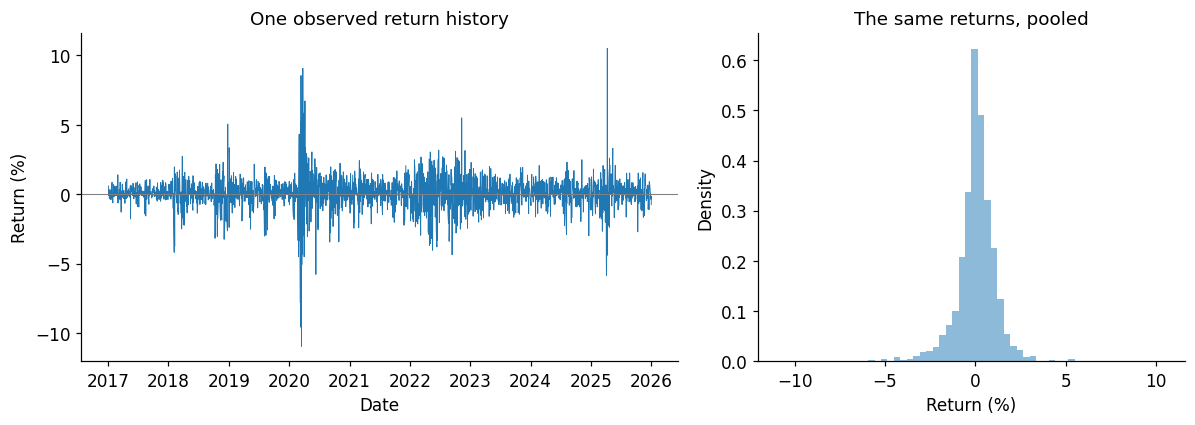

2261 returns: 2017-01-04 to 2025-12-31


In [3]:
spy_prices = pd.read_csv(repository / "data" / "spy_adjusted_prices_2017_2025.csv", parse_dates=["Date"])
spy_dates = spy_prices["Date"].iloc[1:]
spy_return_realization = 100*simple_returns(spy_prices["AdjustedClose"].to_numpy())
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.4, 1]})
axes[0].plot(spy_dates, spy_return_realization, color="C0", linewidth=.6)
axes[0].axhline(0, color="0.5", linewidth=.7)
axes[0].set(title="One observed return history", xlabel="Date", ylabel="Return (%)")
axes[1].hist(spy_return_realization, bins=60, density=True, color="C0", alpha=.5)
axes[1].set(title="The same returns, pooled", xlabel="Return (%)", ylabel="Density")
fig.tight_layout()
plt.show()
print(f"{len(spy_return_realization)} returns: {spy_dates.iloc[0].date()} to {spy_dates.iloc[-1].date()}")


## 3. Describing Downside Risk

With the loss convention introduced above, negative returns appear as positive losses. Two useful summaries are **Value at Risk (VaR)**, the loss threshold exceeded with a specified probability, and **Expected Shortfall (ES)**, the average loss in that tail for a continuous model.

For illustration, the next figure uses a hypothetical Gaussian loss distribution with mean zero and standard deviation two percentage points. It is not fitted to the SPY observations. The shaded region is the upper 5% tail. VaR marks its threshold and ES its average loss. Neither is a maximum possible loss or a guarantee about future observations.

Here the population model is known. In practice its parameters must be estimated, or the tail must be described directly from observed losses. The technical notebooks develop both approaches and distinguish their population quantities from finite-sample estimates.

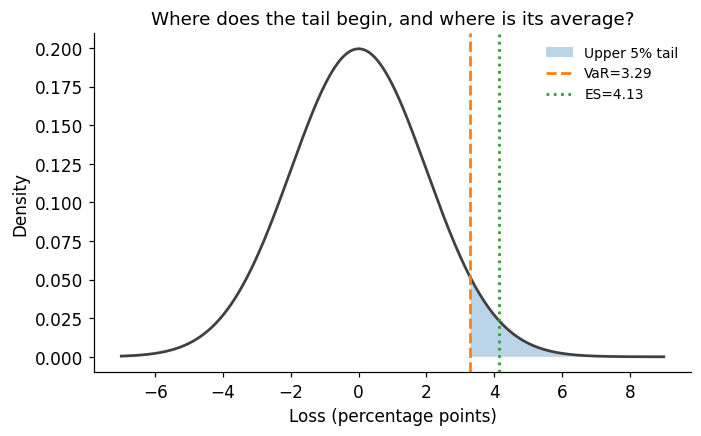

In [4]:
loss_distribution = stats.norm(loc=0, scale=2)
alpha = .05
threshold = loss_distribution.ppf(1-alpha)
tail_average = quad(lambda x: x*loss_distribution.pdf(x), threshold, np.inf)[0]/alpha
loss_grid = np.linspace(-7, 9, 1001)
fig, ax = plt.subplots()
ax.plot(loss_grid, loss_distribution.pdf(loss_grid), color="0.25")
ax.fill_between(loss_grid, loss_distribution.pdf(loss_grid), where=loss_grid>=threshold,
                alpha=.3, label="Upper 5% tail")
ax.axvline(threshold, color="C1", linestyle="--", label=f"VaR={threshold:.2f}")
ax.axvline(tail_average, color="C2", linestyle=":", label=f"ES={tail_average:.2f}")
ax.set(xlabel="Loss (percentage points)", ylabel="Density", title="Where does the tail begin, and where is its average?")
ax.legend(fontsize=9)
plt.show()

## 4. From Distributions to Time Series

The sequence begins with probability models, because expectations and risk estimates depend on what is assumed about possible outcomes.

- **Univariate distributions:** CDFs, densities, quantiles, moments and distributional families, including their population tail properties.
- **Multivariate distributions:** several returns considered together, their marginals and dependence.
- **Statistical inference:** unknown parameters, estimates and their uncertainty.
- **Empirical distributions:** descriptions built directly from observations, including empirical tail estimates and their sampling variability.
- **Financial application:** compare fitted and empirical descriptions on equity and bond returns, then evaluate their frozen predictions out of sample.

These distributional descriptions pool observations. A histogram cannot reveal whether large movements occur together in time or whether risk changes across periods. The time-series notebooks revisit the same financial questions while retaining temporal ordering, beginning with the distinction between a stochastic process and its observed history.
